[0 1 2 3 4]
(2018, 1024) (2018, 1)
[0 1 2 3 4]
(964, 512) (964, 1)
[0 1 2 3 4]
(1545, 256) (1545, 1)


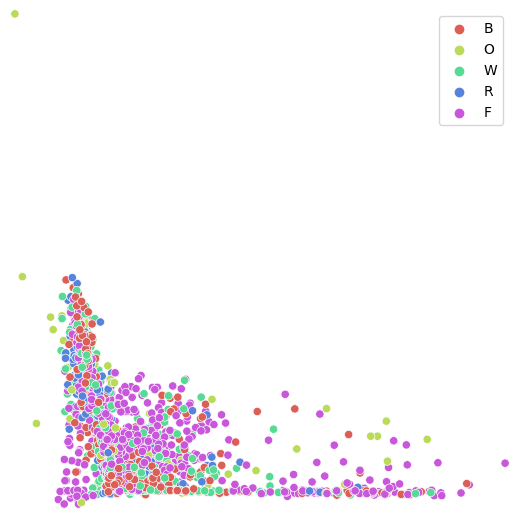

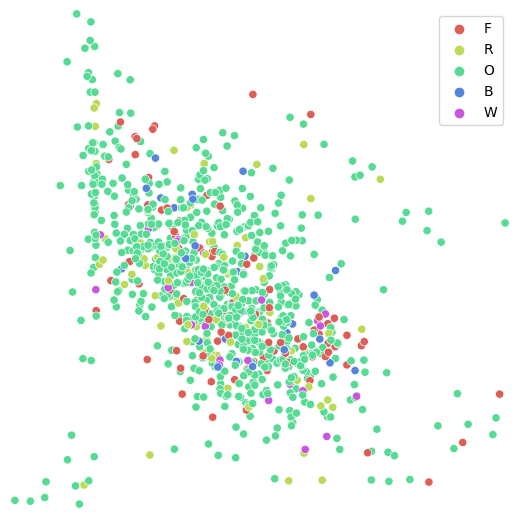

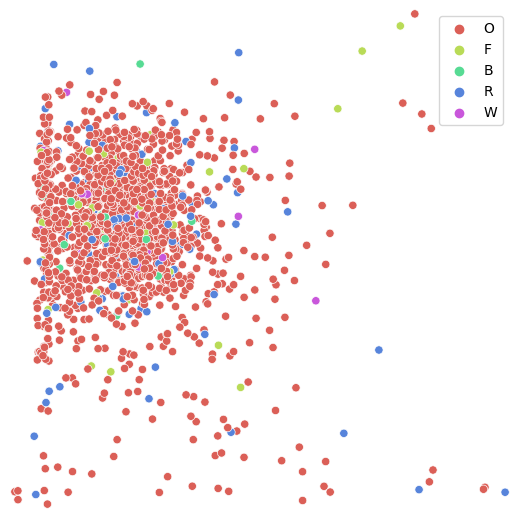

In [5]:
import numpy as np
import torch
import os, sys
from matplotlib import pyplot as plt
import seaborn as sns
save_dir = '/data/yebh/mmdet2/work_dirs/BIS/HPT2HPL/'
save_dir = '/data/yebh/mmdet2/work_dirs/BIS/XQXY2XQY/'
with open(os.path.join(save_dir, 'featurelabel.npy'), 'rb') as f:
    for idx in range(3):
        embed = np.load(f)
        label = np.load(f)
        # print([ele.shape for ele in embed])
        # print([ele.shape for ele in label])
        # print(label.min(), label.max())
        if label.min() == 1:
            label = label - 1

        print(np.unique(label))
        print(embed.shape, label.shape)
        # numpy 拼接 embed以及label
        # embedlabel = np.concatenate((embed, label.reshape(-1,1)), axis=1)
        # print(embedlabel.shape)
        # 去除重复的数据
        # embedlabel = np.unique(embedlabel, axis=0)
        # print(embedlabel.shape)
        # embed = embedlabel[:, :2]
        # label = embedlabel[:, 2]

        # change label to category names
        cates = ['O', 'R', 'B', 'W','F']
        cate_label = []
        for i in range(label.shape[0]):
            cate_label.append(cates[int(label[i])])
        # for i in range(embed.shape[0]):
        #     for j in range(i+1, embed.shape[0]):
        #         if (embed[i] == embed[j]).all() and (i != j):
        #             print(i, j, embed[i], embed[j], label[i], label[j])

        # label = list(lable)
        # draw the scatterplot, ordinnary is embed, label is label
        plt.figure(figsize=(5, 5))
        sns.scatterplot(x=embed[:,0], y=embed[:,1], hue=cate_label,  palette=sns.color_palette("hls", 5))
        # save sns plot
        # 去除边框
        plt.axis('off')
        plt.legend(loc='best')
        # 控制留白
        plt.subplots_adjust(top=1, bottom=0, right=1, left=0, hspace=0, wspace=0)
        plt.margins(0, 0)
        # plt.savefig(os.path.join('/media/data3/yebh/DAOD/SIGMA-main/experiments/sigma/HPT2HPL/v1/', 'tsne.png'), dpi=120)
        plt.savefig(os.path.join(save_dir, f'tsne_{idx}.png'), dpi=120)
        plt.savefig(os.path.join(save_dir, f'tsne_{idx}.pdf'), dpi=120)
    # assert 1==2, 'finish save tsne'